In [1]:
#maybe dont run this on your system...
!mamba install fastcore=1.5.29 

warning  libmamba 'repo.anaconda.com', a commercial channel hosted by Anaconda.com, is used.
    
warning  libmamba Please make sure you understand Anaconda Terms of Services.
    
warning  libmamba See: https://legal.anaconda.com/policies/en/
[+] 0.0s
[+] 0.0s
[+] 0.1s
pkgs/main/noarch ━━━━━━━━━━━╸━━━━━━━━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.0s
pkgs/main/osx-64 ---------------------------   0.0 B /  ??.?MB @  ??.?MB/s  0.0s
pkgs/r/noarch    ━━━━━╸━━━━━━━━━━━━━━━╸━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.0s
pkgs/r/osx-64    ━━━━━━━━━━━━━╸━━━━━━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.0s[+] 0.2s
pkgs/main/noarch ━━━━━━━━━━━━╸━━━━━━━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.1s
pkgs/main/osx-64 ---------------------------   0.0 B /  ??.?MB @  ??.?MB/s  0.1s
pkgs/r/noarch    ━━━━━━╸━━━━━━━━━━━━━━━╸━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.1s
pkgs/r/osx-64    ━━━━━━━━━━━━━━╸━━━━━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.1s
Pinned packages:

  - python=3.10


Transaction

  Prefix: /Users/zoe/.lo

In [2]:
%load_ext autoreload
%autoreload 2

import os
os.environ["SYNTHCITY_DEVICE"] = "cpu"

import tapas
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from tapas.generators.generator import Raw
from utils.my_attack import MyAttack
from utils.benchmark_pipeline import BenchmarkPipeline
from tools.tapas.tapas_data_processors import AdultDataProcessor
import random



from reprosyn.methods import DS_PRIVBAYES
from reprosyn.methods import DS_BAYNET
from tools.tapas.generators import BenchmarkGenerator, SynthcityGenerator, ReprosynGenerator, Raw

/Users/zoe/.local/share/mamba/envs/tapas-upgrade/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [3]:
gen1 = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0)
repr(gen1)

'PrivBayes_epsilon=1.0'

In [4]:
gen2 = SynthcityGenerator("uniform_sampler", label="uniform_sampler")
repr(gen2)

uniform_sampler


'uniform_sampler_random_state=42'

In [5]:
gen3 = Raw()
repr(gen3)

'Raw'

In [3]:
# !pip install tf_keras

2261
estimating categorical probs
estimating approx kdes(histogram)
[0.9274336283185841]
Attacking : PrivBayes_epsilon=1.0
Generate datasets
COMPLEXITY:  2
COMPLEXITY:  10


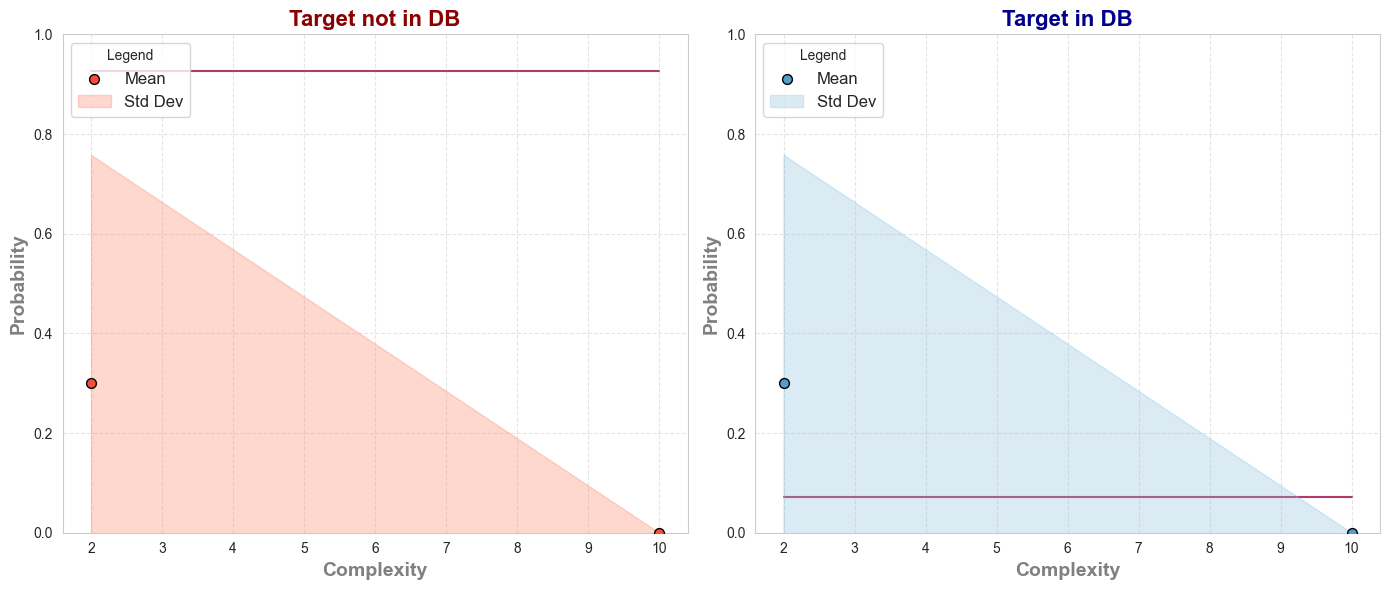

Attacking : uniform_sampler_random_state=42
Generate datasets


[2025-05-07T16:50:34.208002+0100][46756][CRITICAL] module disabled: /Users/zoe/.local/share/mamba/envs/tapas-upgrade/lib/python3.10/site-packages/synthcity/plugins/generic/plugin_goggle.py
[2025-05-07T16:50:37.793175+0100][46756][CRITICAL] module disabled: /Users/zoe/.local/share/mamba/envs/tapas-upgrade/lib/python3.10/site-packages/synthcity/plugins/generic/plugin_goggle.py
[2025-05-07T16:50:37.945652+0100][46756][CRITICAL] module disabled: /Users/zoe/.local/share/mamba/envs/tapas-upgrade/lib/python3.10/site-packages/synthcity/plugins/generic/plugin_goggle.py
[2025-05-07T16:50:38.089582+0100][46756][CRITICAL] module disabled: /Users/zoe/.local/share/mamba/envs/tapas-upgrade/lib/python3.10/site-packages/synthcity/plugins/generic/plugin_goggle.py
[2025-05-07T16:50:38.236975+0100][46756][CRITICAL] module disabled: /Users/zoe/.local/share/mamba/envs/tapas-upgrade/lib/python3.10/site-packages/synthcity/plugins/generic/plugin_goggle.py
[2025-05-07T16:50:38.391383+0100][46756][CRITICAL] modu

COMPLEXITY:  2
COMPLEXITY:  10


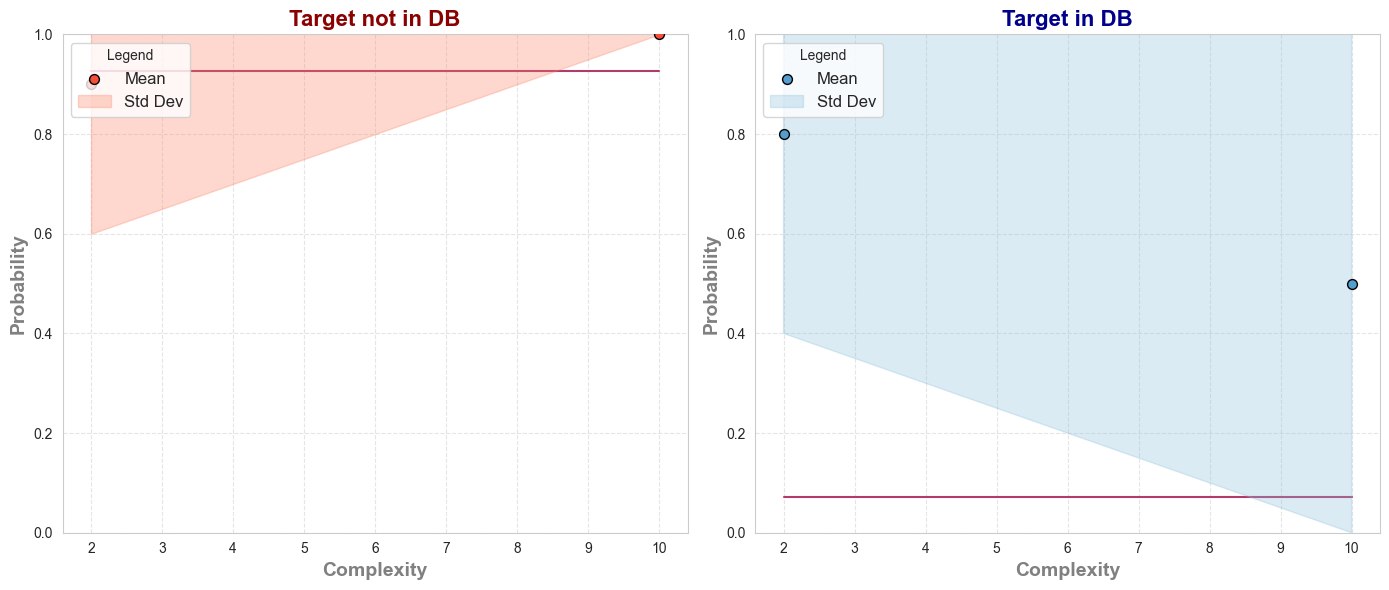

Attacking : Raw
Generate datasets
COMPLEXITY:  2
COMPLEXITY:  10


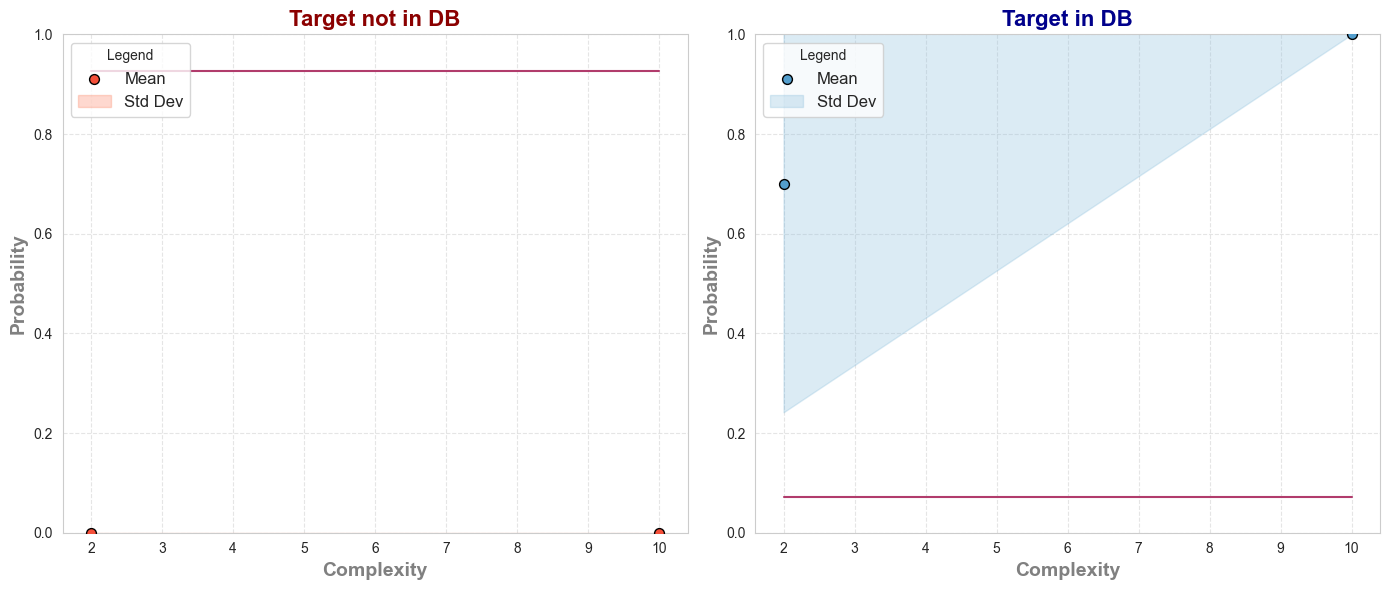

In [7]:
#TEST PIPELINE
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
data = data.sample(frac = 0.05)  #downsample the data 
print(len(data.data))
ind = [int(random.random() * len(data.data))]

target_record = data.get_records(ind)
data.drop_records(ind, in_place=True)

attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,4,2000))
gen = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0)

pipeline = BenchmarkPipeline(data, attack, [gen1,gen2,gen3], target_record=target_record)
pipeline.run([2,10], 10, 2)